In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = pd.read_csv("Desktop/Projects/AgriYield_AI/datasets/Crop_Prediction_dataset.csv")
df = pd.DataFrame(data)

In [12]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (49999, 10)

Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Temperature', 'Humidity', 'Soil_Moisture', 'Area', 'Production']

Data types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Temperature        int64
Humidity           int64
Soil_Moisture      int64
Area             float64
Production       float64
dtype: object


In [13]:
df.isnull().sum()

State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Temperature        0
Humidity           0
Soil_Moisture      0
Area               0
Production       215
dtype: int64

In [14]:
(df.isnull().mean() * 100).round(2)

State_Name       0.00
District_Name    0.00
Crop_Year        0.00
Season           0.00
Crop             0.00
Temperature      0.00
Humidity         0.00
Soil_Moisture    0.00
Area             0.00
Production       0.43
dtype: float64

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
print("Year:", df["Crop_Year"].min(), "-", df["Crop_Year"].max())

print("States:", df["State_Name"].nunique())
print("Districts:", df["District_Name"].nunique())
print("Crops:", df["Crop"].nunique())
print("Seasons:", df["Season"].nunique())

Year: 1997 - 2014
States: 7
Districts: 112
Crops: 80
Seasons: 6


In [17]:
df[[
    "Temperature",
    "Humidity",
    "Soil_Moisture",
    "Area",
    "Production"
]].describe()

,Temperature,Humidity,Soil_Moisture,Area,Production
count,49999.000000,49999.000000,49999.000000,49999.000000,4.978400e+04
mean,34.445489,44.776116,53.110502,7363.389469,4.132019e+05
std,3.498524,6.662406,5.258764,27927.935789,1.232609e+07
min,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,34.000000,40.000000,50.000000,76.000000,8.700000e+01
50%,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,36.000000,50.000000,55.000000,2546.500000,5.615000e+03
max,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


In [18]:
print("Area <= 0:", (df["Area"] <= 0).sum())
print("Production < 0:", (df["Production"] < 0).sum())

Area <= 0: 0
Production < 0: 0


In [19]:
print("Seasons:")
print(df["Season"].value_counts())

print("\nNumber of crops:", df["Crop"].nunique())
print(df["Crop"].value_counts().head(20))

Seasons:
Season
Kharif         17024
Rabi           15657
Whole Year     12654
Summer          2108
Autumn          1428
Winter          1128
Name: count, dtype: int64

Number of crops: 80
Crop
Rice                     3853
Maize                    3249
Moong(Green Gram)        2084
Dry chillies             1595
Arhar/Tur                1578
Urad                     1531
Sugarcane                1517
Wheat                    1497
Sesamum                  1481
Small millets            1396
Gram                     1353
Potato                   1351
Rapeseed &Mustard        1338
Onion                    1314
Linseed                  1202
Turmeric                 1127
Sweet potato             1097
Masoor                   1050
Peas & beans (Pulses)    1046
Banana                    965
Name: count, dtype: int64


In [20]:
print(
    df.groupby("Crop_Year")["State_Name"]
    .nunique()
)

Crop_Year
1997    4
1998    5
1999    5
2000    7
2001    7
2002    7
2003    7
2004    7
2005    7
2006    7
2007    6
2008    6
2009    6
2010    7
2011    5
2012    5
2013    5
2014    5
Name: State_Name, dtype: int64


In [21]:
print(
    df.groupby("State_Name")["Crop_Year"]
    .nunique()
    .sort_values()
)

State_Name
Andaman and Nicobar Islands     8
Chandigarh                     13
Chhattisgarh                   15
Andhra Pradesh                 18
Assam                          18
Arunachal Pradesh              18
Bihar                          18
Name: Crop_Year, dtype: int64


In [23]:
df.groupby(
    ["Temperature", "Humidity", "Soil_Moisture"]
).size().sort_values(ascending=False).head(20)

Temperature  Humidity  Soil_Moisture
36           41        50               5557
             40        54               5557
37           42        55               5557
36           35        45               5556
34           45        52               5556
37           40        46               5556
34           55        62               5555
35           50        59               5554
25           55        55               5551
dtype: int64

In [24]:
df["Yield"] = df["Production"] / df["Area"]

In [25]:
df["Yield"].describe()

count    49784.000000
mean        84.233237
std        929.707033
min          0.000000
25%          0.616852
50%          1.053023
75%          2.876939
max      33089.005477
Name: Yield, dtype: float64

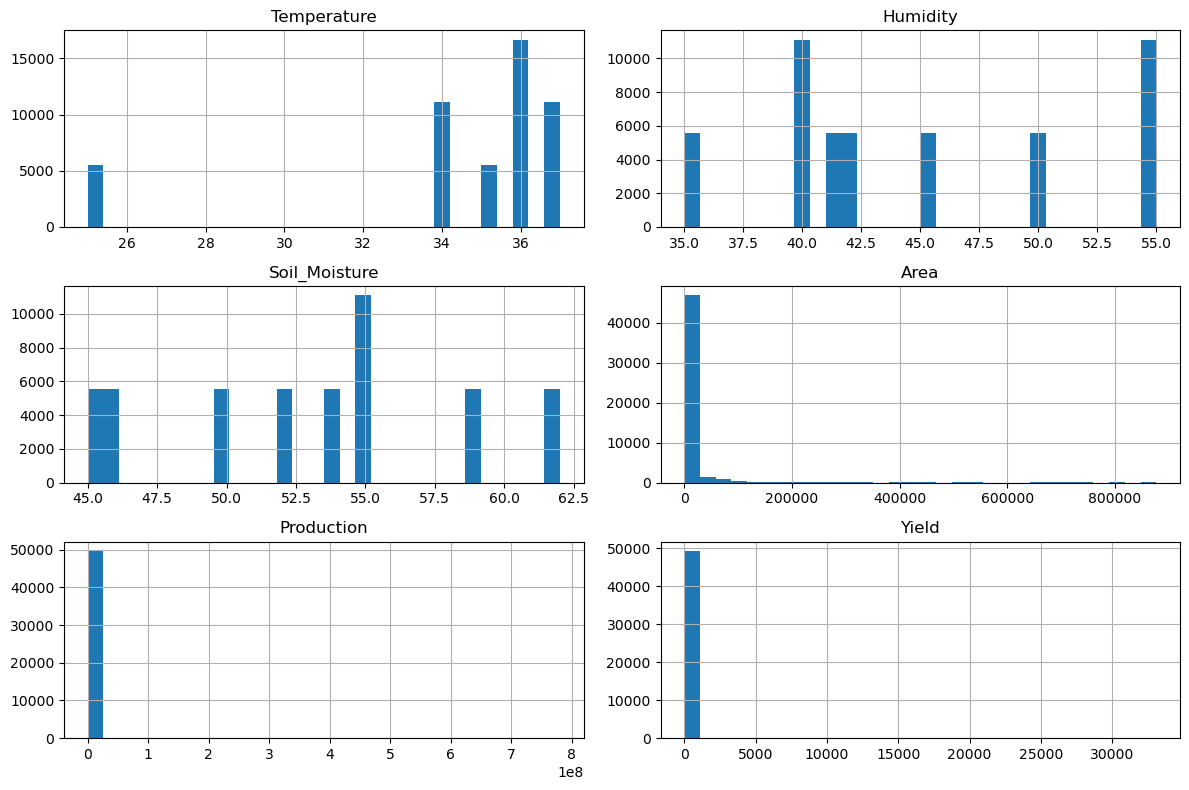

In [28]:
numeric_cols = [
    "Temperature",
    "Humidity",
    "Soil_Moisture",
    "Area",
    "Production",
    "Yield"
]

df[numeric_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

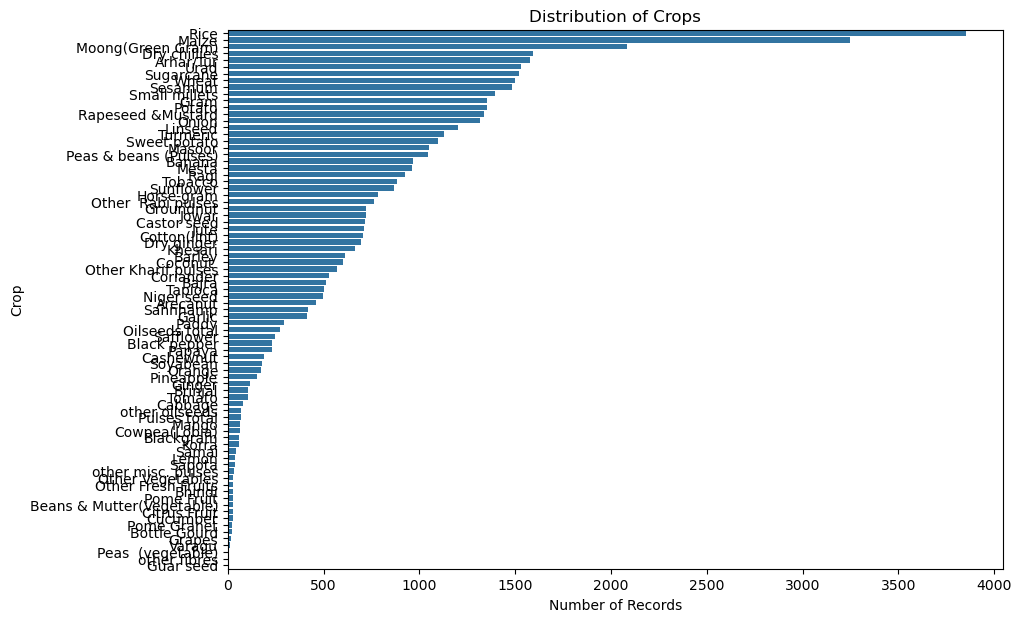

In [29]:
plt.figure(figsize=(10, 7))

sns.countplot(
    data=df,
    y="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

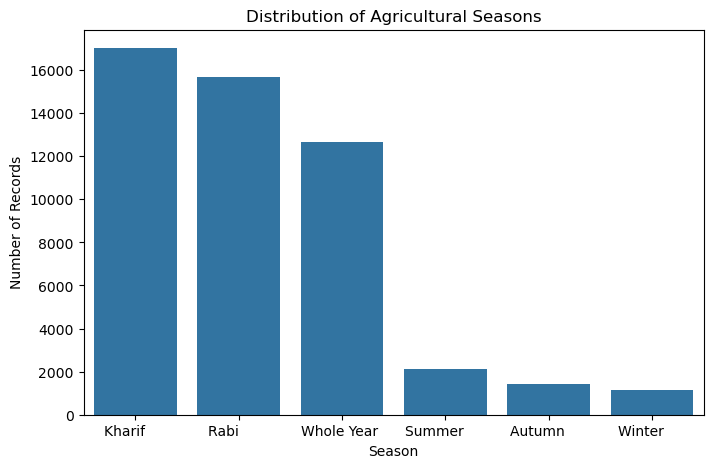

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

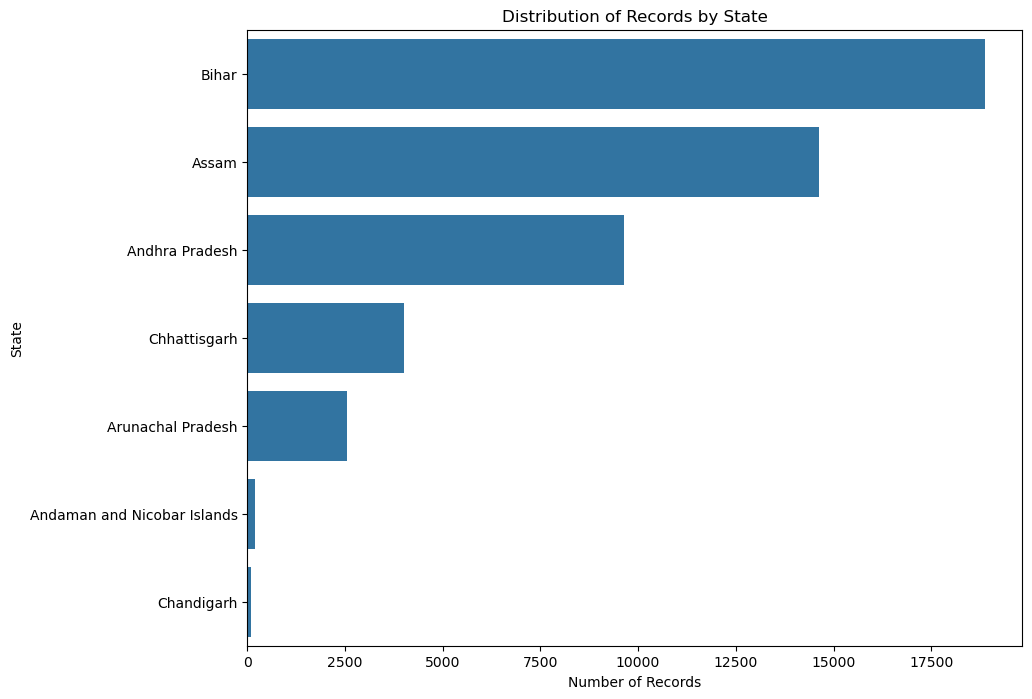

In [31]:
plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    y="State_Name",
    order=df["State_Name"].value_counts().index
)

plt.title("Distribution of Records by State")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.show()

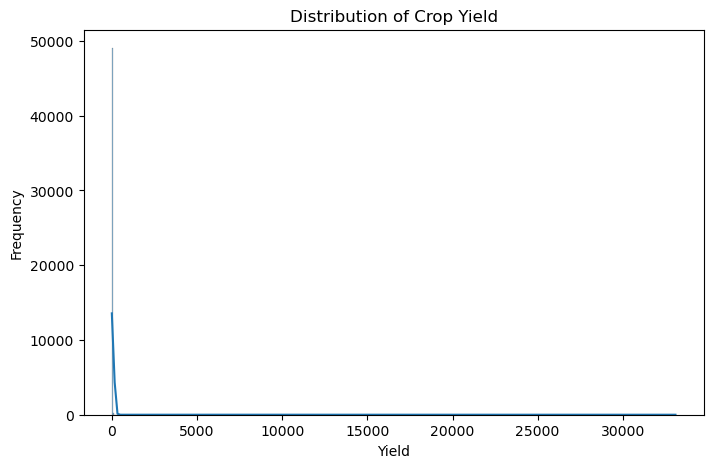

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Yield",
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

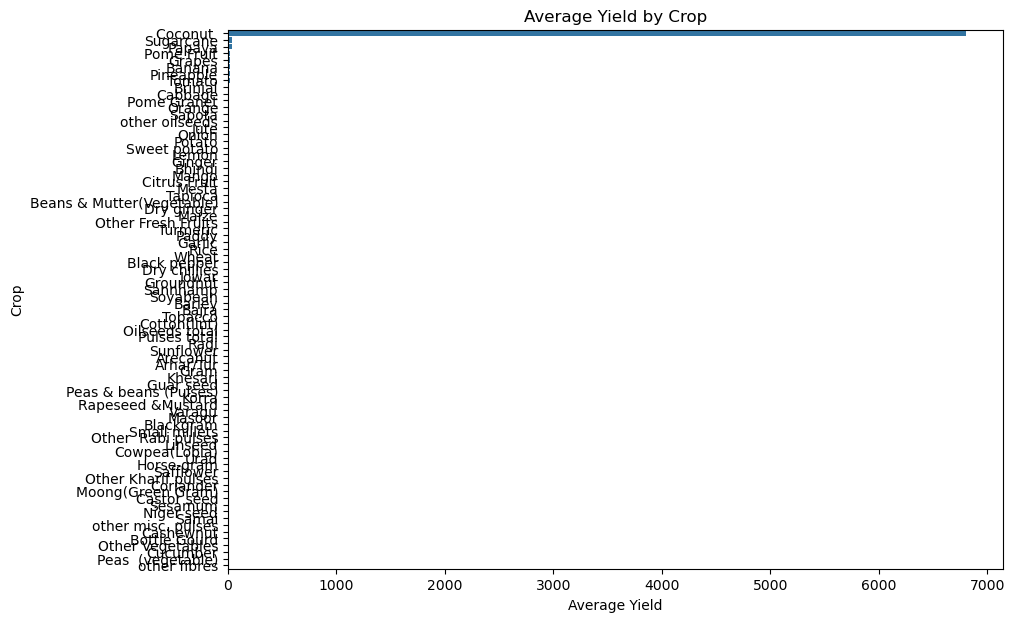

In [34]:
crop_yield = (
    df.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title("Average Yield by Crop")
plt.xlabel("Average Yield")
plt.ylabel("Crop")
plt.show()

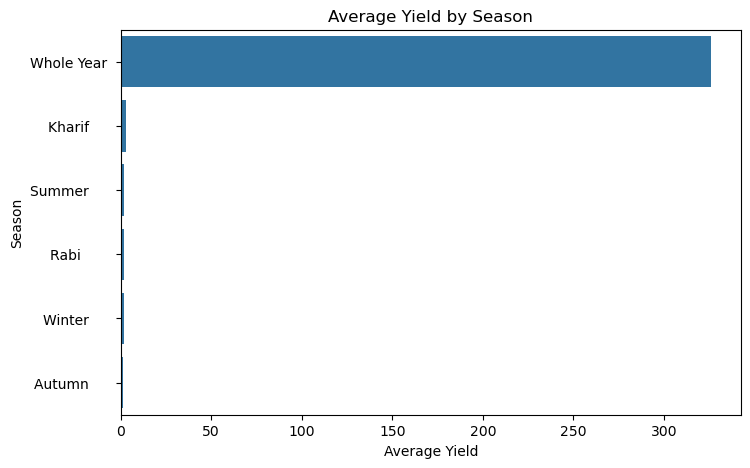

In [35]:
season_yield = (
    df.groupby("Season")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.values,
    y=season_yield.index
)

plt.title("Average Yield by Season")
plt.xlabel("Average Yield")
plt.ylabel("Season")
plt.show()

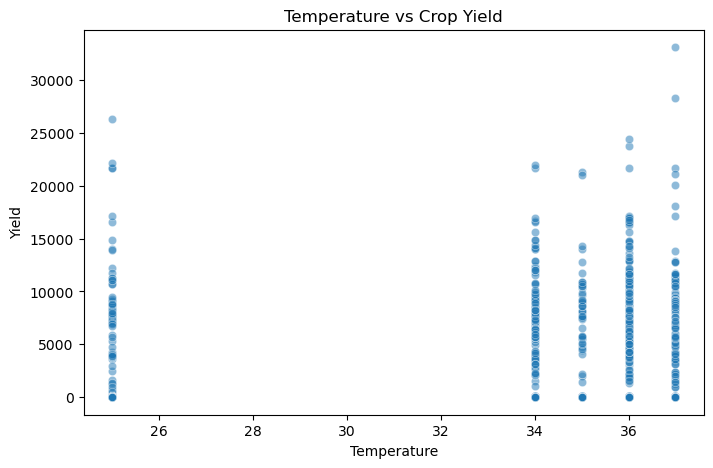

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Yield",
    alpha=0.5
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.show()

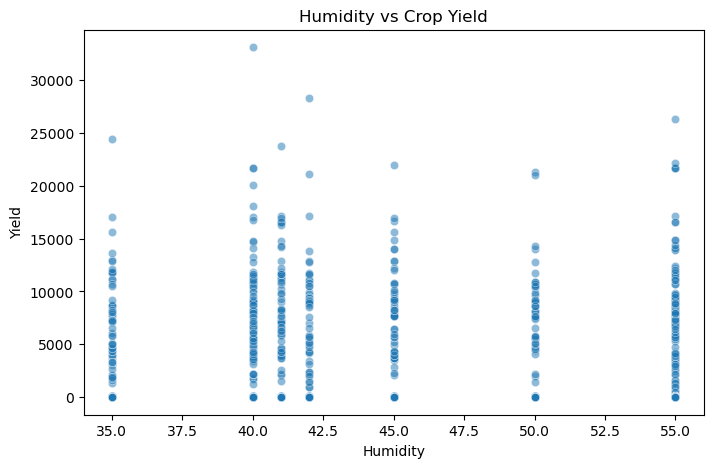

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Humidity",
    y="Yield",
    alpha=0.5
)

plt.title("Humidity vs Crop Yield")
plt.xlabel("Humidity")
plt.ylabel("Yield")
plt.show()

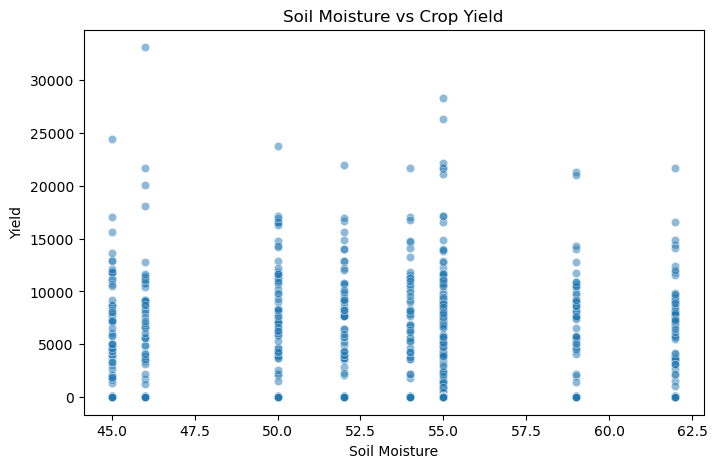

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Soil_Moisture",
    y="Yield",
    alpha=0.5
)

plt.title("Soil Moisture vs Crop Yield")
plt.xlabel("Soil Moisture")
plt.ylabel("Yield")
plt.show()

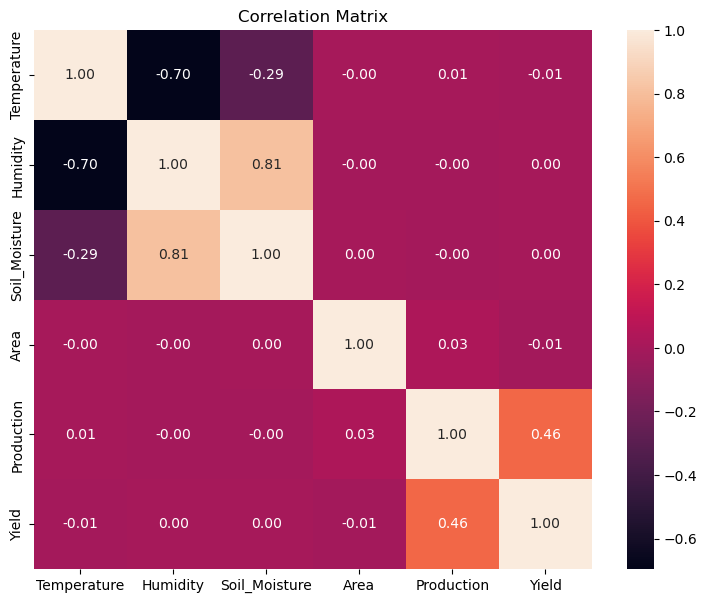

In [39]:
corr_cols = [
    "Temperature",
    "Humidity",
    "Soil_Moisture",
    "Area",
    "Production",
    "Yield"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

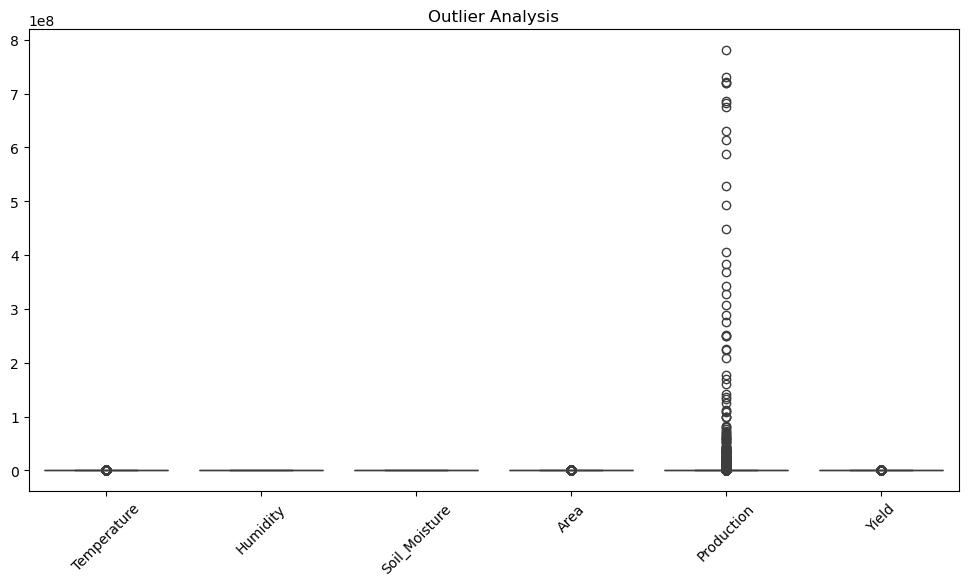

In [40]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Analysis")
plt.xticks(rotation=45)
plt.show()

In [41]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    print(f"{col}: {count} potential outliers")

Temperature: 5551 potential outliers
Humidity: 0 potential outliers
Soil_Moisture: 0 potential outliers
Area: 8033 potential outliers
Production: 8452 potential outliers
Yield: 8092 potential outliers


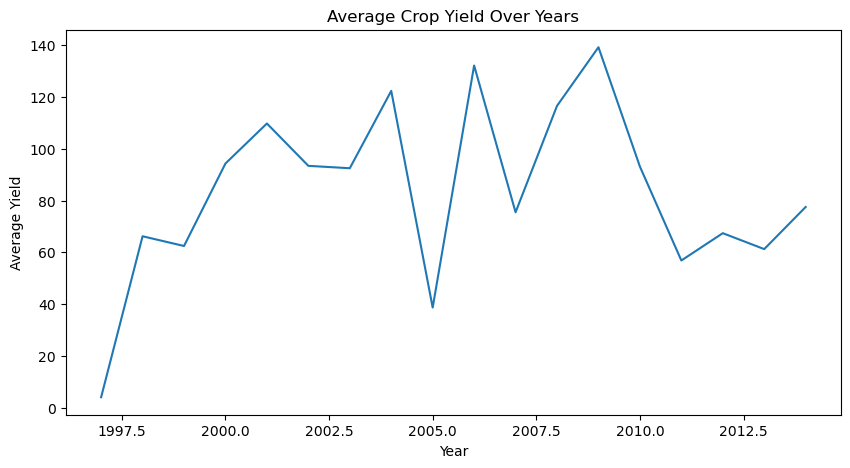

In [42]:
yearly_yield = (
    df.groupby("Crop_Year")["Yield"]
    .mean()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_yield.index,
    y=yearly_yield.values
)

plt.title("Average Crop Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.show()

In [ ]:
# ## Combined Dataset EDA Findings

# - The combined dataset integrates agricultural, weather, and
#   soil-moisture information at the state/district/year/crop level.

# - The dataset covers the period from 1997 to 2014, providing
#   historical agricultural observations.

# - Crop, season, and state distributions were analyzed to understand
#   the structure and coverage of the agricultural records.

# - Yield was derived from Production and Area and used as the main
#   target variable for exploratory analysis.

# - Yield varies considerably across different crops and seasons.

# - Temperature, humidity, and soil moisture were analyzed to examine
#   their potential relationship with crop yield.

# - Correlation analysis was performed to identify relationships between
#   numerical agricultural and environmental variables.

# - Potential outliers were identified using the IQR method and will
#   be investigated before deciding on treatment.

# - Historical yield trends were examined across the available years.

# - The combined dataset provides a stronger foundation for the
#   subsequent yield-prediction stage because agricultural,
#   environmental, and soil-moisture attributes are available within
#   the same dataset.